# Titanic Survival Prediction — Logistic Regression

Complete workflow: EDA, preprocessing, feature engineering, Logistic Regression, evaluation, strategy comparison, tuning, and coefficient interpretation.

**Important:** preprocessing is fitted on training data only using scikit-learn pipelines. Loading the Seaborn dataset may require internet access.

## Cell 1 — Imports

Import the libraries used in this notebook.

In [1]:
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, ConfusionMatrixDisplay, confusion_matrix
)

RANDOM_STATE = 42
pd.set_option("display.max_columns", None)

## Cell 2 — Load data

Load Seaborn's Titanic dataset and keep an unchanged working copy.

In [2]:
df = sns.load_dataset("titanic").copy()
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## Cell 3 — Shape and column names

Check the number of rows/columns and inspect the column names.

In [3]:
print("Shape:", df.shape)
print(df.columns.tolist())

Shape: (891, 15)
['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']


## Cell 4 — Data types and non-null counts

`info()` shows column types, non-null counts, and memory usage.

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


## Cell 5 — Missing values

Count missing values and calculate their percentage. This is exploration only; imputation happens after splitting.

In [5]:
missing_summary = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": (df.isna().mean() * 100).round(2)
}).sort_values("missing_percent", ascending=False)
display(missing_summary)

,missing_count,missing_percent
deck,688,77.22
age,177,19.87
embarked,2,0.22
embark_town,2,0.22
sex,0,0.00
pclass,0,0.00
survived,0,0.00
fare,0,0.00
parch,0,0.00
sibsp,0,0.00


## Cell 6 — Descriptive statistics

Use `describe()` for numeric statistics and `describe(include='all')` for all columns.

In [6]:
display(df.describe())
display(df.describe(include="all"))

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
count,891.000000,891.000000,891,714.000000,891.000000,891.000000,891.000000,889,891,891,891,203,889,891,891
unique,NaN,NaN,2,NaN,NaN,NaN,NaN,3,3,3,2,7,3,2,2
top,NaN,NaN,male,NaN,NaN,NaN,NaN,S,Third,man,True,C,Southampton,no,True
freq,NaN,NaN,577,NaN,NaN,NaN,NaN,644,491,537,537,59,644,549,537
mean,0.383838,2.308642,NaN,29.699118,0.523008,0.381594,32.204208,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,0.486592,0.836071,NaN,14.526497,1.102743,0.806057,49.693429,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000,1.000000,NaN,0.420000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,0.000000,2.000000,NaN,20.125000,0.000000,0.000000,7.910400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,0.000000,3.000000,NaN,28.000000,0.000000,0.000000,14.454200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,1.000000,3.000000,NaN,38.000000,1.000000,0.000000,31.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Cell 7 — Target distribution

Count survivors (1) and non-survivors (0), and plot the distribution.

survived
Did not survive    549
Survived           342
Name: count, dtype: int64
survived
0    61.62
1    38.38
Name: proportion, dtype: float64


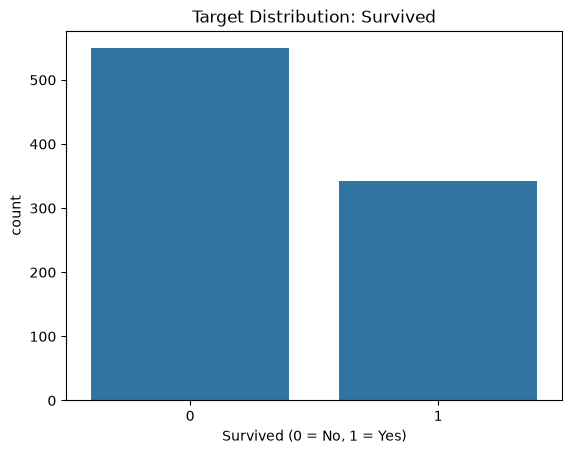

In [7]:
print(df["survived"].value_counts().sort_index().rename(index={0: "Did not survive", 1: "Survived"}))
print((df["survived"].value_counts(normalize=True).sort_index() * 100).round(2))
sns.countplot(data=df, x="survived")
plt.title("Target Distribution: Survived")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.show()

## Cell 8 — Survival rate by sex and class

Because `survived` is 0/1, its mean is the survival rate.

,count,sum,mean
sex,,,
female,314,233,0.742038
male,577,109,0.188908


,count,sum,mean
pclass,,,
1,216,136,0.629630
2,184,87,0.472826
3,491,119,0.242363


count  sum      mean
sex    pclass                      
female 1          94   91  0.968085
       2          76   70  0.921053
       3         144   72  0.500000
male   1         122   45  0.368852
       2         108   17  0.157407
       3         347   47  0.135447

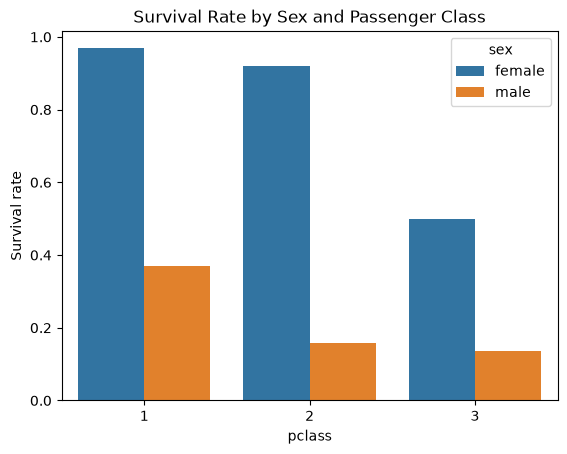

In [8]:
display(df.groupby("sex", observed=True)["survived"].agg(["count", "sum", "mean"]))
display(df.groupby("pclass", observed=True)["survived"].agg(["count", "sum", "mean"]))
display(df.groupby(["sex", "pclass"], observed=True)["survived"].agg(["count", "sum", "mean"]))
sns.barplot(data=df, x="pclass", y="survived", hue="sex", errorbar=None)
plt.title("Survival Rate by Sex and Passenger Class")
plt.ylabel("Survival rate")
plt.show()

## Cell 9 — Duplicate inspection

Exact duplicates are not automatically erroneous passenger records. Do not remove them without evidence of data-entry/import errors.

In [9]:
print("Exact duplicate rows:", df.duplicated().sum())
display(df[df.duplicated(keep=False)].head(20))

Exact duplicate rows: 107


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
26,0,3,male,NaN,0,0,7.2250,C,Third,man,True,NaN,Cherbourg,no,True
28,1,3,female,NaN,0,0,7.8792,Q,Third,woman,False,NaN,Queenstown,yes,True
29,0,3,male,NaN,0,0,7.8958,S,Third,man,True,NaN,Southampton,no,True
32,1,3,female,NaN,0,0,7.7500,Q,Third,woman,False,NaN,Queenstown,yes,True
37,0,3,male,21.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
42,0,3,male,NaN,0,0,7.8958,C,Third,man,True,NaN,Cherbourg,no,True
45,0,3,male,NaN,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
46,0,3,male,NaN,1,0,15.5000,Q,Third,man,True,NaN,Queenstown,no,False
47,1,3,female,NaN,0,0,7.7500,Q,Third,woman,False,NaN,Queenstown,yes,True


## Cell 10 — Define target and select features

Use `survived` as `y`. Exclude `alive` because it reveals the target; avoid redundant `class`/`pclass` and `embark_town`/`embarked`. Omit high-missingness `deck` and identifier/free-text columns for this first model.

In [10]:
feature_columns = ["pclass", "sex", "age", "sibsp", "parch", "fare", "embarked"]
X = df[feature_columns].copy()
y = df["survived"].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Target included in X?", "survived" in X.columns)
print("Selected features:", X.columns.tolist())

X shape: (891, 7)
y shape: (891,)
Target included in X? False
Selected features: ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']


## Cell 11 — Feature engineering

Create family size and an alone indicator from existing features. These transformations do not use the target.

In [11]:
X["family_size"] = X["sibsp"] + X["parch"] + 1
X["is_alone"] = (X["family_size"] == 1).astype(int)
display(X.head())

,pclass,sex,age,sibsp,parch,fare,embarked,family_size,is_alone
0,3,male,22.0,1,0,7.2500,S,2,0
1,1,female,38.0,1,0,71.2833,C,2,0
2,3,female,26.0,0,0,7.9250,S,1,1
3,1,female,35.0,1,0,53.1000,S,2,0
4,3,male,35.0,0,0,8.0500,S,1,1


## Cell 12 — Separate numerical and categorical features

Treat `pclass` as categorical even though it is represented by numbers.

In [12]:
numerical_features = ["age", "sibsp", "parch", "fare", "family_size", "is_alone"]
categorical_features = ["pclass", "sex", "embarked"]
print("Numerical:", numerical_features)
print("Categorical:", categorical_features)
display(X[numerical_features].dtypes.rename("dtype").to_frame())
display(X[categorical_features].dtypes.rename("dtype").to_frame())

Numerical: ['age', 'sibsp', 'parch', 'fare', 'family_size', 'is_alone']
Categorical: ['pclass', 'sex', 'embarked']


,dtype
age,float64
sibsp,int64
parch,int64
fare,float64
family_size,int64
is_alone,int64


,dtype
pclass,int64
sex,str
embarked,str


## Cell 13 — Train/test split

Split before fitting imputers, encoders, or scalers. `stratify=y` approximately preserves target proportions.

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)
print("X_train:", X_train.shape, "X_test:", X_test.shape)
print("y_train:", y_train.shape, "y_test:", y_test.shape)
print("Train survival rate:", round(y_train.mean(), 3))
print("Test survival rate:", round(y_test.mean(), 3))

X_train: (712, 9) X_test: (179, 9)
y_train: (712,) y_test: (179,)
Train survival rate: 0.383
Test survival rate: 0.385


## Cell 14 — Build preprocessing and modeling pipeline

Numeric: median imputation + standard scaling. Categorical: most-frequent imputation + one-hot encoding. The pipeline fits preprocessing on training data only.

In [14]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numerical_features),
    ("cat", categorical_pipeline, categorical_features)
])
baseline_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))
])
baseline_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3I

## Cell 15 — Train the baseline model

Fit the complete pipeline. The imputer, encoder, and scaler are learned from `X_train` only.

In [15]:
baseline_model.fit(X_train, y_train)
print("Model trained.")
print("Iterations used:", baseline_model.named_steps["classifier"].n_iter_)

Model trained.
Iterations used: [17]


## Cell 16 — Predict classes and probabilities

`predict()` returns labels; `predict_proba()` returns estimated class probabilities.

In [16]:
y_pred = baseline_model.predict(X_test)
y_proba = baseline_model.predict_proba(X_test)[:, 1]
predictions_preview = pd.DataFrame({
    "actual_survived": y_test,
    "predicted_survived": y_pred,
    "predicted_survival_probability": y_proba
}, index=y_test.index)
display(predictions_preview.head(10))

,actual_survived,predicted_survived,predicted_survival_probability
565,0,0,0.085736
160,0,0,0.075026
553,1,0,0.141751
860,0,0,0.046915
241,1,1,0.745831
559,1,1,0.531370
387,1,1,0.732713
536,0,0,0.287210
698,0,0,0.372632
99,0,0,0.230228


## Cell 17 — Evaluate the model

Calculate accuracy, precision, recall, F1-score, and the classification report on held-out test data.

In [17]:
test_metrics = {
    "accuracy": accuracy_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred, zero_division=0),
    "recall": recall_score(y_test, y_pred, zero_division=0),
    "f1_score": f1_score(y_test, y_pred, zero_division=0)
}
display(pd.Series(test_metrics, name="test_score").to_frame())
print(classification_report(
    y_test, y_pred,
    target_names=["Did not survive", "Survived"],
    zero_division=0
))

,test_score
accuracy,0.815642
precision,0.810345
recall,0.681159
f1_score,0.740157


                 precision    recall  f1-score   support

Did not survive       0.82      0.90      0.86       110
       Survived       0.81      0.68      0.74        69

       accuracy                           0.82       179
      macro avg       0.81      0.79      0.80       179
   weighted avg       0.82      0.82      0.81       179



## Cell 18 — Confusion matrix

False positive: predicted survival, actual non-survival. False negative: predicted non-survival, actual survival.

Rows = actual, columns = predicted:
 [[99 11]
 [22 47]]


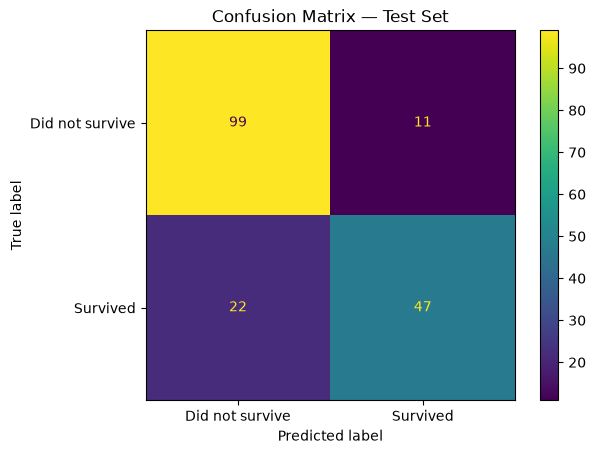

In [18]:
cm = confusion_matrix(y_test, y_pred)
print("Rows = actual, columns = predicted:\n", cm)
ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Did not survive", "Survived"]
).plot(values_format="d")
plt.title("Confusion Matrix — Test Set")
plt.show()

## Cell 19 — Compare training and test accuracy

A large gap can suggest overfitting. Similar low scores can suggest underfitting, but these metrics alone are not definitive.

In [19]:
train_pred = baseline_model.predict(X_train)
train_accuracy = accuracy_score(y_train, train_pred)
test_accuracy = accuracy_score(y_test, y_pred)
print(f"Training accuracy: {train_accuracy:.3f}")
print(f"Test accuracy:     {test_accuracy:.3f}")
print(f"Absolute gap:      {abs(train_accuracy - test_accuracy):.3f}")

Training accuracy: 0.802
Test accuracy:     0.816
Absolute gap:      0.014


## Cell 20 — Probabilities and classification threshold

Inspect predicted probabilities. The default threshold is 0.5; changing it trades precision against recall. Do not choose a threshold by optimizing the test set.

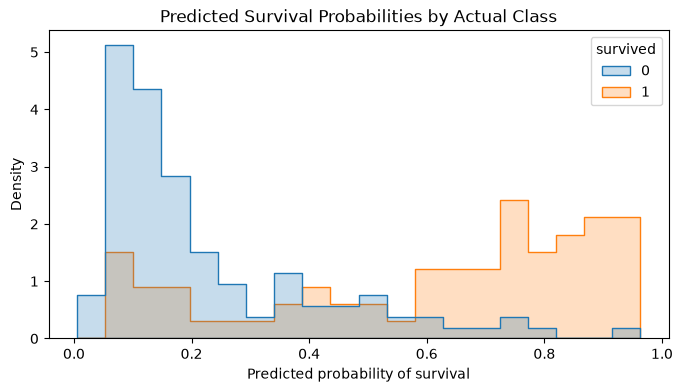

Metrics at threshold=0.40
Accuracy: 0.799
Precision: 0.732
Recall: 0.754
F1: 0.743


In [20]:
plt.figure(figsize=(8, 4))
sns.histplot(x=y_proba, hue=y_test, bins=20, stat="density", common_norm=False, element="step")
plt.title("Predicted Survival Probabilities by Actual Class")
plt.xlabel("Predicted probability of survival")
plt.show()

threshold = 0.40
y_pred_threshold = (y_proba >= threshold).astype(int)
print(f"Metrics at threshold={threshold:.2f}")
print("Accuracy:", round(accuracy_score(y_test, y_pred_threshold), 3))
print("Precision:", round(precision_score(y_test, y_pred_threshold, zero_division=0), 3))
print("Recall:", round(recall_score(y_test, y_pred_threshold, zero_division=0), 3))
print("F1:", round(f1_score(y_test, y_pred_threshold, zero_division=0), 3))

## Cell 21 — Challenge A: Compare preprocessing strategies

Compare median vs mean imputation for numeric features, and most-frequent vs a dedicated missing category for categorical features. Each pipeline is fitted on training data only.

In [21]:
def make_model(numeric_strategy="median", categorical_strategy="most_frequent", C=1.0):
    num_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy=numeric_strategy)),
        ("scaler", StandardScaler())
    ])
    cat_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy=categorical_strategy, fill_value="Missing")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ])
    prep = ColumnTransformer([
        ("num", num_pipe, numerical_features),
        ("cat", cat_pipe, categorical_features)
    ])
    return Pipeline([
        ("preprocessor", prep),
        ("classifier", LogisticRegression(C=C, max_iter=2000, random_state=RANDOM_STATE))
    ])

strategy_models = {
    "Median + most_frequent": make_model("median", "most_frequent"),
    "Mean + Missing category": make_model("mean", "constant")
}
strategy_results = []
for name, model in strategy_models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    strategy_results.append({
        "strategy": name,
        "accuracy": accuracy_score(y_test, pred),
        "precision": precision_score(y_test, pred, zero_division=0),
        "recall": recall_score(y_test, pred, zero_division=0),
        "f1_score": f1_score(y_test, pred, zero_division=0)
    })
strategy_results = pd.DataFrame(strategy_results).set_index("strategy")
display(strategy_results.sort_values("f1_score", ascending=False))

,accuracy,precision,recall,f1_score
strategy,,,,
Median + most_frequent,0.815642,0.810345,0.681159,0.740157
Mean + Missing category,0.810056,0.796610,0.681159,0.734375


## Cell 22 — Challenge B: Tune regularization `C`

Smaller `C` means stronger regularization; larger `C` means weaker regularization. Use cross-validation on training data for model selection.

In [22]:
tuning_model = make_model("median", "most_frequent")
param_grid = {"classifier__C": [0.01, 0.1, 1.0, 10.0, 100.0]}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
grid_search = GridSearchCV(
    tuning_model, param_grid, scoring="f1", cv=cv,
    n_jobs=-1, return_train_score=True
)
grid_search.fit(X_train, y_train)
print("Best parameters:", grid_search.best_params_)
print("Best mean CV F1:", round(grid_search.best_score_, 3))
cv_results = pd.DataFrame(grid_search.cv_results_)[[
    "param_classifier__C", "mean_train_score", "mean_test_score",
    "std_test_score", "rank_test_score"
]].sort_values("param_classifier__C")
display(cv_results)

Best parameters: {'classifier__C': 0.1}
Best mean CV F1: 0.726


,param_classifier__C,mean_train_score,mean_test_score,std_test_score,rank_test_score
0,0.01,0.618312,0.604389,0.062593,5
1,0.10,0.732237,0.725859,0.022703,1
2,1.00,0.733962,0.723494,0.022811,2
3,10.00,0.735862,0.723494,0.022811,2
4,100.00,0.735256,0.723494,0.022811,2


## Cell 23 — Evaluate tuned model

Evaluate the best cross-validated model on the held-out test set.

In [23]:
best_model = grid_search.best_estimator_
tuned_pred = best_model.predict(X_test)
print("Tuned test accuracy:", round(accuracy_score(y_test, tuned_pred), 3))
print("Tuned test precision:", round(precision_score(y_test, tuned_pred, zero_division=0), 3))
print("Tuned test recall:", round(recall_score(y_test, tuned_pred, zero_division=0), 3))
print("Tuned test F1:", round(f1_score(y_test, tuned_pred, zero_division=0), 3))
print(classification_report(
    y_test, tuned_pred,
    target_names=["Did not survive", "Survived"],
    zero_division=0
))

Tuned test accuracy: 0.821
Tuned test precision: 0.814
Tuned test recall: 0.696
Tuned test F1: 0.75
                 precision    recall  f1-score   support

Did not survive       0.82      0.90      0.86       110
       Survived       0.81      0.70      0.75        69

       accuracy                           0.82       179
      macro avg       0.82      0.80      0.81       179
   weighted avg       0.82      0.82      0.82       179



## Cell 24 — Challenge C: Interpret coefficients

Positive coefficients increase log-odds of survival and negative coefficients decrease them, holding other encoded features constant. This describes model associations, not causation.

,feature,coefficient
9,cat__sex_female,1.043273
10,cat__sex_male,-1.041591
8,cat__pclass_3,-0.724686
6,cat__pclass_1,0.623563
0,num__age,-0.354530
5,num__is_alone,-0.289927
13,cat__embarked_S,-0.256760
1,num__sibsp,-0.244213
3,num__fare,0.220868
4,num__family_size,-0.192514


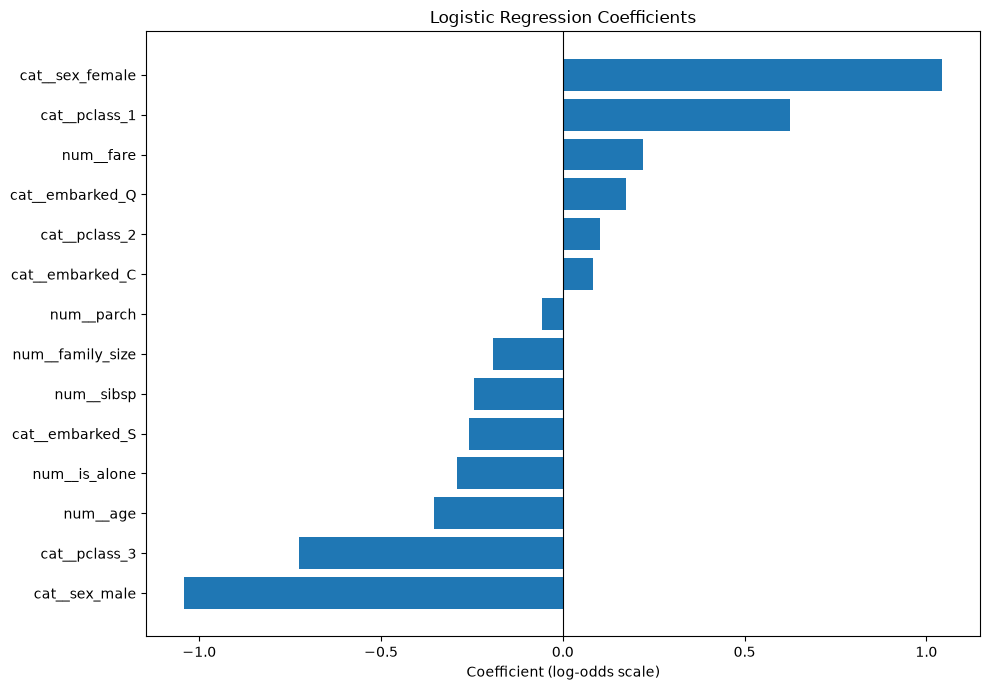

In [24]:
fitted_preprocessor = best_model.named_steps["preprocessor"]
fitted_classifier = best_model.named_steps["classifier"]
feature_names = fitted_preprocessor.get_feature_names_out()
coefficients = pd.DataFrame({
    "feature": feature_names,
    "coefficient": fitted_classifier.coef_[0]
})
coefficients["absolute_coefficient"] = coefficients["coefficient"].abs()
coefficients = coefficients.sort_values("absolute_coefficient", ascending=False)
display(coefficients.drop(columns="absolute_coefficient"))

plot_coefficients = coefficients.sort_values("coefficient")
plt.figure(figsize=(10, 7))
plt.barh(plot_coefficients["feature"], plot_coefficients["coefficient"])
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Logistic Regression Coefficients")
plt.xlabel("Coefficient (log-odds scale)")
plt.tight_layout()
plt.show()

## Cell 25 — Final model comparison

Compare baseline and tuned models on the same held-out test set. Use cross-validation—not repeated test-set experimentation—for future model selection.

In [25]:
final_comparison = pd.DataFrame([
    {
        "model": "Baseline Logistic Regression",
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1_score": f1_score(y_test, y_pred, zero_division=0)
    },
    {
        "model": "Tuned Logistic Regression",
        "accuracy": accuracy_score(y_test, tuned_pred),
        "precision": precision_score(y_test, tuned_pred, zero_division=0),
        "recall": recall_score(y_test, tuned_pred, zero_division=0),
        "f1_score": f1_score(y_test, tuned_pred, zero_division=0)
    }
]).set_index("model")
display(final_comparison.round(3))

,accuracy,precision,recall,f1_score
model,,,,
Baseline Logistic Regression,0.816,0.810,0.681,0.74
Tuned Logistic Regression,0.821,0.814,0.696,0.75


## Cell 26 — Write your conclusion

Complete these prompts in your own words using your actual outputs.

In [26]:
print("CONCLUSION CHECKLIST")
print("1. Best model and why: ______________________________")
print("2. Most useful features according to coefficients: ____")
print("3. Main error type (false positives/negatives): _______")
print("4. Evidence of overfitting/underfitting: ______________")
print("5. Limitation or next experiment: ____________________")

CONCLUSION CHECKLIST
1. Best model and why: ______________________________
2. Most useful features according to coefficients: ____
3. Main error type (false positives/negatives): _______
4. Evidence of overfitting/underfitting: ______________
5. Limitation or next experiment: ____________________


## Final checklist

- [x] EDA and missing-value analysis
- [x] Target and feature selection; prevent target leakage
- [x] Duplicate inspection without automatically deleting legitimate records
- [x] Feature engineering (`family_size`, `is_alone`)
- [x] Reproducible stratified train/test split
- [x] Imputation, encoding, and scaling in a pipeline
- [x] Logistic Regression, predictions, and probabilities
- [x] Metrics, classification report, and confusion matrix
- [x] Train/test comparison and threshold experiment
- [x] Compare preprocessing strategies
- [x] Cross-validated tuning of `C`
- [x] Coefficient interpretation

**Note:** Scores depend on the split and library versions. Use cross-validation on training data for model selection; reserve the test set for final evaluation.